In [85]:
# ===============================================================================
# PREVISÃO DE TEMPERATURA HORÁRIA EM BELÉM (PA) - RESUMO
# ===============================================================================

# Equipe:
# - Antônio Lucas Costa Araújo | antoniolucas9028@gmail.com
# - Evandro José da Silva Mariano | evandromariano49@gmail.com
# - Iago Oliveira de Sousa | iago.sousa@castanhal.ufpa.br
#
# Este projeto prevê a temperatura horária em Belém (PA) usando três algoritmos
# de regressão: Regressão Linear, Random Forest e SVR.
#
# Principais etapas:
# - Carregar e pré-processar dados meteorológicos do INMET
# - Criar variáveis derivadas (engenharia de features)
# - Treinar e avaliar modelos com MSE, RMSE, MAE e R²
# - Visualizar resultados e gerar previsão para o dia seguinte
# - Salvar automaticamente os modelos treinados (.pkl)
#
# Dados:
# - Fonte: INMET, estação Belém (A001)
# - Frequência: Horária
# - Variáveis: Temperatura, Umidade, Pressão, Vento, Radiação e Chuva


In [86]:
# =============================================================================
# SEÇÃO 1: IMPORTAÇÃO DE BIBLIOTECAS
# =============================================================================
# Esta seção importa todas as bibliotecas necessárias para o projeto

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
import pickle
import os  # Para verificar existência de arquivos

# NOVA: Supressão de warnings
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# NOVA: Supressão específica do scikit-learn
try:
    from sklearn.exceptions import InconsistentVersionWarning
    warnings.filterwarnings('ignore', category=InconsistentVersionWarning)
except ImportError:
    pass


In [87]:
# =============================================================================
# SEÇÃO 2: CONFIGURAÇÃO INICIAL E VERIFICAÇÃO DE MODELOS PRÉ-TREINADOS
# =============================================================================
# Esta seção configura o estilo dos gráficos e verifica se existem modelos já treinados

# Configuração de estilo para os gráficos
plt.style.use('seaborn-v0_8-darkgrid')
palette = sns.color_palette("husl", 3)

# Verificação de modelos pré-treinados
def verificar_modelos_existentes():
    """
    Verifica se todos os modelos pré-treinados existem no diretório
    Retorna True se todos existirem, False caso contrário
    """
    modelos_necessarios = [
        'modelo_random_forest.pkl',
        'modelo_regressão_linear.pkl',
        'modelo_svr.pkl'
    ]

    todos_existem = all(os.path.exists(modelo) for modelo in modelos_necessarios)

    if todos_existem:
        print("✅ Todos os modelos pré-treinados foram encontrados!")
        print("📁 Modelos disponíveis:")
        for modelo in modelos_necessarios:
            print(f"   - {modelo}")
        return True
    else:
        print("❌ Alguns modelos pré-treinados não foram encontrados.")
        print("🔍 Modelos disponíveis:")
        for modelo in modelos_necessarios:
            status = "✅" if os.path.exists(modelo) else "❌"
            print(f"   {status} {modelo}")
        return False

# Executa a verificação
modelos_existentes = verificar_modelos_existentes()

✅ Todos os modelos pré-treinados foram encontrados!
📁 Modelos disponíveis:
   - modelo_random_forest.pkl
   - modelo_regressão_linear.pkl
   - modelo_svr.pkl


In [88]:
# =============================================================================
# SEÇÃO 3: CARREGAMENTO E PRÉ-PROCESSAMENTO DE DADOS
# =============================================================================
# Esta seção contém as funções para carregar e preparar os dados meteorológicos

def carregar_dados(caminho_arquivo='Belem.csv'):
    """
    Carrega e processa dados meteorológicos de um arquivo CSV
    Esta função lê o arquivo CSV, limpa os dados e converte para DataFrame
    """
    # Verifica se o arquivo existe
    if not os.path.exists(caminho_arquivo):
        print(f"❌ Arquivo não encontrado: {caminho_arquivo}")
        print("📁 Arquivos disponíveis no diretório atual:")
        arquivos = [f for f in os.listdir('.') if f.endswith('.csv')]
        if arquivos:
            print("   Arquivos CSV encontrados:")
            for arquivo in arquivos:
                print(f"   - {arquivo}")
        else:
            print("   Nenhum arquivo CSV encontrado")
        return None

    try:
        with open(caminho_arquivo, 'r', encoding='utf-8') as f:
            linhas = f.readlines()

        dados = []
        for linha in linhas[2:]:
            linha_limpa = linha.strip().replace('"', '')
            partes = linha_limpa.split(';')

            linha_processada = []
            for parte in partes:
                parte = parte.strip()
                if ',' in parte and parte.replace(',', '').replace('.', '').isdigit():
                    parte = parte.replace('.', '').replace(',', '.')
                linha_processada.append(parte)

            dados.append(linha_processada)

        colunas = [
            'Data', 'Hora', 'Temp_Inst', 'Temp_Max', 'Temp_Min',
            'Umidade_Inst', 'Umidade_Max', 'Umidade_Min',
            'Orvalho_Inst', 'Orvalho_Max', 'Orvalho_Min',
            'Pressao_Inst', 'Pressao_Max', 'Pressao_Min',
            'Vento_Vel', 'Vento_Dir', 'Vento_Rajada', 'Radiacao', 'Chuva'
        ]

        df = pd.DataFrame(dados, columns=colunas)
        numeric_cols = df.columns.drop(['Data', 'Hora'])
        df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

        df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y', errors='coerce')
        df['Hora'] = df['Hora'].astype(str).str.zfill(4)
        df['DateTime'] = pd.to_datetime(
            df['Data'].dt.strftime('%Y-%m-%d') + ' ' + df['Hora'].str[:2] + ':' + df['Hora'].str[2:]
        )

        df = df.dropna(subset=['DateTime'])
        print('✅ Dados carregados com sucesso!')
        print(f"�� Total de registros: {len(df)}")
        return df

    except Exception as e:
        print(f"❌ Erro ao carregar os dados: {e}")
        return None

def preprocessar_dados(df):
    """
    Pré-processamento dos dados e criação de novas features
    Esta função cria variáveis temporais e de engenharia de features
    """
    print("🔧 Iniciando pré-processamento dos dados...")

    # Criação de variáveis temporais
    df['Hora_num'] = df['DateTime'].dt.hour
    df['Dia'] = df['DateTime'].dt.day
    df['Mes'] = df['DateTime'].dt.month
    df['Ano'] = df['DateTime'].dt.year
    df['Dia_do_ano'] = df['DateTime'].dt.dayofyear
    df['Dia_da_semana'] = df['DateTime'].dt.dayofweek

    # Criação de features cíclicas para hora (seno e cosseno)
    df['Hora_sin'] = np.sin(2 * np.pi * df['Hora_num']/24)
    df['Hora_cos'] = np.cos(2 * np.pi * df['Hora_num']/24)

    # Média móvel da temperatura (últimas 24 horas)
    df['Temp_Media_Movel'] = df['Temp_Inst'].rolling(24, min_periods=1).mean()

    # Preenchimento de valores ausentes com mediana
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].fillna(df[col].median())

    print("✅ Pré-processamento concluído!")
    return df

In [89]:
# =============================================================================
# SEÇÃO 4: FUNÇÕES DE VISUALIZAÇÃO E GRÁFICOS
# =============================================================================
# Esta seção contém todas as funções para criar gráficos e visualizações

def plot_comparacao_real_vs_previsto(previsoes):
    """
    Plota gráfico comparativo entre valores reais e previstos
    Mostra como cada modelo se compara com a temperatura real
    """
    plt.figure(figsize=(15, 7))

    plt.plot(previsoes['DataHora'], previsoes['Temperatura_Real'],
             '-', color='black', linewidth=2, label='Temperatura Real')

    modelos = ['Regressão Linear', 'Random Forest', 'SVR']
    for i, modelo in enumerate(modelos):
        plt.plot(previsoes['DataHora'], previsoes[f'{modelo}_Previsto'],
                '--', color=palette[i], linewidth=1.5, alpha=0.8,
                label=f'{modelo} Previsto')

    plt.title('Comparação entre Temperatura Real e Previsões dos Modelos', fontsize=14)
    plt.xlabel('Data e Hora', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_margem_erro(previsoes):
    """
    Plota a margem de erro absoluto dos modelos
    Mostra o erro absoluto de cada modelo ao longo do tempo
    """
    plt.figure(figsize=(15, 6))

    modelos = ['Regressão Linear', 'Random Forest', 'SVR']
    for i, modelo in enumerate(modelos):
        plt.plot(previsoes['DataHora'], previsoes[f'{modelo}_Margem_Erro'],
                '-', color=palette[i], linewidth=1.5, alpha=0.7,
                label=f'Margem de Erro {modelo}')

    plt.title('Margem de Erro Absoluto dos Modelos', fontsize=14)
    plt.xlabel('Data e Hora', fontsize=12)
    plt.ylabel('Erro Absoluto (°C)', fontsize=12)
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_erros_temporais(previsoes):
    """
    Plota a evolução temporal dos erros de previsão
    Mostra como os erros variam ao longo do tempo para cada modelo
    """
    plt.figure(figsize=(15, 8))

    modelos = ['Regressão Linear', 'Random Forest', 'SVR']
    for i, modelo in enumerate(modelos):
        plt.plot(previsoes['DataHora'], previsoes[f'{modelo}_Erro'],
                '-', color=palette[i], alpha=0.7, linewidth=1,
                label=f'Erro {modelo}')

    plt.title('Evolução Temporal dos Erros de Previsão', fontsize=14)
    plt.xlabel('Data e Hora', fontsize=12)
    plt.ylabel('Erro (Temperatura Real - Prevista) °C', fontsize=12)
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_distribuicao_erros(previsoes):
    """
    Plota a distribuição dos erros de previsão
    Mostra a distribuição estatística dos erros para cada modelo
    """
    plt.figure(figsize=(15, 6))
    modelos = ['Regressão Linear', 'Random Forest', 'SVR']

    for i, modelo in enumerate(modelos):
        sns.kdeplot(previsoes[f'{modelo}_Erro'], color=palette[i],
                   label=modelo, linewidth=2)

    plt.title('Distribuição dos Erros de Previsão', fontsize=14)
    plt.xlabel('Erro (Temperatura Real - Prevista) °C', fontsize=12)
    plt.ylabel('Densidade', fontsize=12)
    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_metricas_comparativas(resultados):
    """
    Plota gráficos comparativos das métricas dos modelos
    Compara RMSE, MAE e R² entre os diferentes modelos
    """
    metricas = ['RMSE', 'MAE', 'R²']
    plt.figure(figsize=(15, 5))

    for i, metrica in enumerate(metricas):
        plt.subplot(1, 3, i+1)
        sns.barplot(x='Modelo', y=metrica, data=resultados,
                   hue='Modelo', palette=palette, legend=False)
        plt.title(f'Comparação de {metrica}', fontsize=12)
        plt.xticks(rotation=45)
        if metrica == 'R²':
            plt.ylim(0.9, 1.0)

    plt.tight_layout()
    plt.show()

def plot_erros_por_hora(df, previsoes):
    """
    Plota erros médios por hora do dia
    Mostra como o erro varia ao longo das 24 horas do dia
    """
    df_erros = df[['DateTime', 'Hora_num']].merge(
        previsoes, left_on='DateTime', right_on='DataHora')

    modelos = ['Regressão Linear', 'Random Forest', 'SVR']
    plt.figure(figsize=(15, 6))

    for i, modelo in enumerate(modelos):
        erro_medio = df_erros.groupby('Hora_num')[f'{modelo}_Margem_Erro'].mean()
        plt.plot(erro_medio.index, erro_medio.values,
                '-o', color=palette[i], linewidth=2, markersize=6,
                label=modelo)

    plt.title('Erro Médio Absoluto por Hora do Dia', fontsize=14)
    plt.xlabel('Hora do Dia', fontsize=12)
    plt.ylabel('Erro Médio Absoluto (°C)', fontsize=12)
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [90]:
# =============================================================================
# SEÇÃO 5: CARREGAMENTO E TREINAMENTO DE MODELOS
# =============================================================================
# Esta seção contém as funções para carregar modelos existentes ou treinar novos

def carregar_modelos_existentes():
    """
    Carrega modelos pré-treinados dos arquivos .pkl
    Retorna os modelos carregados e suas features
    """
    print("�� Carregando modelos pré-treinados...")

    modelos_carregados = []
    features = None

    try:
        # Suprime warnings de versão incompatível do scikit-learn
        import warnings
        warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

        # Carrega cada modelo
        with open('modelo_random_forest.pkl', 'rb') as f:
            modelo_rf = pickle.load(f)
            modelos_carregados.append(('Random Forest', modelo_rf))
            features = modelo_rf['features']
            print("✅ Random Forest carregado com sucesso")

        with open('modelo_regressão_linear.pkl', 'rb') as f:
            modelo_lr = pickle.load(f)
            modelos_carregados.append(('Regressão Linear', modelo_lr))
            print("✅ Regressão Linear carregada com sucesso")

        with open('modelo_svr.pkl', 'rb') as f:
            modelo_svr = pickle.load(f)
            modelos_carregados.append(('SVR', modelo_svr))
            print("✅ SVR carregado com sucesso")

        print("🎯 Todos os modelos foram carregados com sucesso!")
        return modelos_carregados, features

    except Exception as e:
        print(f"❌ Erro ao carregar modelos: {e}")
        return None, None

def treinar_e_avaliar(df):
    """
    Treina e avalia os modelos de previsão
    Esta função cria, treina e salva os modelos de machine learning
    """
    print("🚀 Iniciando treinamento dos modelos...")

    # Definição das features (variáveis de entrada) e target (variável de saída)
    features = [
        'Hora_num', 'Dia', 'Mes', 'Ano', 'Dia_do_ano', 'Dia_da_semana',
        'Hora_sin', 'Hora_cos',
        'Umidade_Inst', 'Orvalho_Inst', 'Pressao_Inst',
        'Vento_Vel', 'Vento_Dir', 'Radiacao', 'Chuva',
        'Temp_Media_Movel'
    ]
    target = 'Temp_Inst'

    # Preparação dos dados para treinamento
    X = df[features]
    y = df[target]

    # Divisão em conjunto de treinamento e teste (80% treino, 20% teste)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False)

    # Definição dos modelos com seus hiperparâmetros
    modelos = [
        ('Regressão Linear', make_pipeline(
            MinMaxScaler(),  # Normalização dos dados
            LinearRegression()  # Modelo de regressão linear
        )),
        ('Random Forest', make_pipeline(
            MinMaxScaler(),  # Normalização dos dados
            RandomForestRegressor(
                n_estimators=200,      # Número de árvores
                max_depth=10,          # Profundidade máxima das árvores
                min_samples_split=5,   # Mínimo de amostras para dividir
                random_state=42        # Semente para reprodutibilidade
            )
        )),
        ('SVR', make_pipeline(
            MinMaxScaler(),  # Normalização dos dados
            SVR(kernel='rbf', C=10, gamma='auto', epsilon=0.5)  # Support Vector Regression
        ))
    ]

    # Lista para armazenar resultados e DataFrame para previsões
    resultados = []
    previsoes = pd.DataFrame({
        'DataHora': df.loc[X_test.index, 'DateTime'],
        'Temperatura_Real': y_test.values
    })

    # Treinamento e avaliação de cada modelo
    for nome, modelo in modelos:
        print(f"\n🔧 Treinando {nome}...")

        # Treinamento do modelo
        modelo.fit(X_train, y_train)

        # Previsões no conjunto de teste
        y_pred = modelo.predict(X_test)

        # Cálculo das métricas de erro
        erro = y_test.values - y_pred
        margem_erro = np.abs(erro)
        percentual_erro = (margem_erro / y_test.values) * 100

        # Armazenamento das previsões
        previsoes[f'{nome}_Previsto'] = y_pred
        previsoes[f'{nome}_Erro'] = erro
        previsoes[f'{nome}_Margem_Erro'] = margem_erro
        previsoes[f'{nome}_%_Erro'] = percentual_erro

        # Cálculo das métricas de avaliação
        resultados.append({
            'Modelo': nome,
            'MSE': mean_squared_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'R²': r2_score(y_test, y_pred),
            'Erro_Médio_Absoluto': np.mean(margem_erro),
            'Erro_Perc_Médio': np.mean(percentual_erro)
        })

        # Salvamento do modelo treinado
        nome_arquivo = f'modelo_{nome.lower().replace(" ", "_")}.pkl'
        with open(nome_arquivo, 'wb') as f:
            pickle.dump({'model': modelo, 'features': features}, f)
        print(f"�� Modelo salvo em: {nome_arquivo}")

    print("✅ Treinamento concluído com sucesso!")
    return pd.DataFrame(resultados), previsoes, features

In [91]:
# =============================================================================
# SEÇÃO 6: FUNÇÕES DE PREVISÃO E AVALIAÇÃO
# =============================================================================
# Esta seção contém as funções para fazer previsões e avaliar os modelos
# Copie esta seção para a sexta célula do seu notebook

def prever_temperatura_amanha(df, modelos_treinados, features):
    """
    Preve a temperatura média para o dia seguinte
    Esta função usa os modelos treinados para prever a temperatura de amanhã
    """
    print("🔮 Fazendo previsão para amanhã...")

    # Cálculo da data de amanhã (dinâmica)
    ultima_data = df['DateTime'].max()
    amanha = ultima_data + pd.Timedelta(days=1)

    # Dados das últimas 24 horas para usar como referência
    ultimas_24h = df[df['DateTime'] >= (ultima_data - pd.Timedelta(days=1))]

    # Preparação das features para amanhã (24 horas)
    features_amanha = {
        'Hora_num': [h for h in range(24)],  # Horas de 0 a 23
        'Dia': [amanha.day] * 24,            # Dia do mês
        'Mes': [amanha.month] * 24,          # Mês
        'Ano': [amanha.year] * 24,           # Ano
        'Dia_do_ano': [amanha.dayofyear] * 24,  # Dia do ano (1-365)
        'Dia_da_semana': [amanha.dayofweek] * 24,  # Dia da semana (0-6)
        'Hora_sin': np.sin(2 * np.pi * np.array(range(24))/24).tolist(),  # Seno da hora
        'Hora_cos': np.cos(2 * np.pi * np.array(range(24))/24).tolist(),  # Cosseno da hora
        'Umidade_Inst': [ultimas_24h['Umidade_Inst'].median()] * 24,     # Umidade média das últimas 24h
        'Orvalho_Inst': [ultimas_24h['Orvalho_Inst'].median()] * 24,     # Orvalho médio das últimas 24h
        'Pressao_Inst': [ultimas_24h['Pressao_Inst'].median()] * 24,     # Pressão média das últimas 24h
        'Vento_Vel': [ultimas_24h['Vento_Vel'].median()] * 24,          # Velocidade do vento média
        'Vento_Dir': [ultimas_24h['Vento_Dir'].mode()[0]] * 24,         # Direção do vento mais comum
        'Radiacao': [ultimas_24h['Radiacao'].median()] * 24,            # Radiação média
        'Chuva': [ultimas_24h['Chuva'].median()] * 24,                  # Chuva média
        'Temp_Media_Movel': [ultimas_24h['Temp_Inst'].median()] * 24    # Temperatura média móvel
    }

    # Criação do DataFrame com as features de amanhã
    df_amanha = pd.DataFrame(features_amanha)
    X_amanha = df_amanha[features]

    # Dicionário para armazenar as previsões médias (sem data fixa)
    medias_previstas = {}

    # Previsão para cada modelo
    for nome, modelo_info in modelos_treinados:
        modelo = modelo_info['model']
        previsoes = modelo.predict(X_amanha)
        medias_previstas[f'Média {nome}'] = np.mean(previsoes)

    print("✅ Previsão concluída!")
    return medias_previstas

def avaliar_modelos_existentes(df, modelos_treinados):
    """
    Avalia modelos pré-treinados existentes usando a MESMA metodologia do artigo original.
    Retorna os resultados, previsões e features.
    """
    print("🚀 Avaliando modelos pré-treinados existentes...")

    # Definição das features (variáveis de entrada) e target (variável de saída)
    features = [
        'Hora_num', 'Dia', 'Mes', 'Ano', 'Dia_do_ano', 'Dia_da_semana',
        'Hora_sin', 'Hora_cos',
        'Umidade_Inst', 'Orvalho_Inst', 'Pressao_Inst',
        'Vento_Vel', 'Vento_Dir', 'Radiacao', 'Chuva',
        'Temp_Media_Movel'
    ]
    target = 'Temp_Inst'

    # Preparação dos dados para avaliação - MESMA METODOLOGIA DO ARTIGO
    X = df[features]
    y = df[target]

    # Divisão em conjunto de treinamento e teste (80% treino, 20% teste) - IGUAL AO ARTIGO
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False)

    # Lista para armazenar resultados e DataFrame para previsões
    resultados = []
    previsoes = pd.DataFrame({
        'DataHora': df.loc[X_test.index, 'DateTime'],
        'Temperatura_Real': y_test.values
    })

    # Avaliação de cada modelo usando apenas dados de TESTE
    for nome, modelo_info in modelos_treinados:
        print(f"\n🔍 Avaliando {nome}...")

        # Previsões APENAS no conjunto de teste (20% dos dados)
        y_pred = modelo_info['model'].predict(X_test)

        # Cálculo das métricas de erro
        erro = y_test.values - y_pred
        margem_erro = np.abs(erro)
        percentual_erro = (margem_erro / y_test.values) * 100

        # Armazenamento das previsões
        previsoes[f'{nome}_Previsto'] = y_pred
        previsoes[f'{nome}_Erro'] = erro
        previsoes[f'{nome}_Margem_Erro'] = margem_erro
        previsoes[f'{nome}_%_Erro'] = percentual_erro

        # Cálculo das métricas de avaliação - IGUAL AO ARTIGO
        resultados.append({
            'Modelo': nome,
            'MSE': mean_squared_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'R²': r2_score(y_test, y_pred),
            'Erro_Médio_Absoluto': np.mean(margem_erro),
            'Erro_Perc_Médio': np.mean(percentual_erro)
        })

    print("✅ Avaliação concluída!")
    return pd.DataFrame(resultados), previsoes, features

In [92]:
# =============================================================================
# SEÇÃO 7: FUNÇÃO PRINCIPAL E EXECUÇÃO
# =============================================================================
# Esta seção contém a função principal que coordena todo o processo

def main():
    """
    Função principal que executa todo o fluxo do projeto
    Coordena o carregamento, treinamento e avaliação dos modelos
    """
    print("🚀 INICIANDO ANÁLISE DE PREVISÃO DE TEMPERATURA")
    print("=" * 60)

    # PASSO 1: Carregamento dos dados
    print("\n📊 PASSO 1: Carregando dados meteorológicos...")
    df = carregar_dados()

    if df is None:
        print("❌ Falha no carregamento dos dados. Encerrando...")
        return

    # PASSO 2: Pré-processamento dos dados
    print("\n🔧 PASSO 2: Pré-processando dados...")
    df = preprocessar_dados(df)

    # PASSO 3: Verificação de modelos existentes e decisão de treinamento
    print("\n🔍 PASSO 3: Verificando modelos existentes...")

    if modelos_existentes:
        print("�� Usando modelos pré-treinados existentes!")
        modelos_treinados, features = carregar_modelos_existentes()

        if modelos_treinados is None:
            print("❌ Erro ao carregar modelos. Treinando novos modelos...")
            resultados, previsoes, features = treinar_e_avaliar(df)
        else:
            print("✅ Modelos carregados com sucesso!")
            # Avaliando modelos existentes com dados de teste
            print("\n📈 AVALIANDO MODELOS PRÉ-TREINADOS...")
            resultados, previsoes, features = avaliar_modelos_existentes(df, modelos_treinados)
    else:
        print("🚀 Treinando novos modelos...")
        resultados, previsoes, features = treinar_e_avaliar(df)

    # PASSO 4: Exibição dos resultados
    print("\n�� PASSO 4: DASHBOARD DE RESULTADOS")
    print("=" * 60)
    print("🏆 RESULTADOS DOS MODELOS:")
    print("=" * 60)
    print(resultados.to_string(index=False))

    # PASSO 5: Carregamento dos modelos treinados para previsão
    print("\n📥 PASSO 5: Carregando modelos para previsão...")
    modelos_treinados = []
    for nome in ['Regressão Linear', 'Random Forest', 'SVR']:
        with open(f'modelo_{nome.lower().replace(" ", "_")}.pkl', 'rb') as f:
            modelos_treinados.append((nome, pickle.load(f)))

    # PASSO 6: Previsão para o próximo dia
    print("\n🔮 PASSO 6: Prevendo temperatura média para o próximo dia...")
    previsao_media_proximo_dia = prever_temperatura_amanha(df, modelos_treinados, features)

    print("\n��️ PREVISÃO MÉDIA DE TEMPERATURA PARA O PRÓXIMO DIA:")
    print("=" * 50)
    print(f"📊 Média Regressão Linear: {previsao_media_proximo_dia['Média Regressão Linear']:.2f}°C")
    print(f"🌳 Média Random Forest: {previsao_media_proximo_dia['Média Random Forest']:.2f}°C")
    print(f"�� Média SVR: {previsao_media_proximo_dia['Média SVR']:.2f}°C")

    # PASSO 7: Geração dos gráficos de análise
    print("\n�� PASSO 7: GERANDO DASHBOARD VISUAL COMPLETO...")
    print("🎨 Criando gráficos interativos e atrativos...")

    # Dashboard completo com todos os gráficos
    plot_comparacao_real_vs_previsto(previsoes)
    plot_margem_erro(previsoes)
    plot_erros_temporais(previsoes)
    plot_distribuicao_erros(previsoes)
    plot_metricas_comparativas(resultados)
    plot_erros_por_hora(df, previsoes)

    # PASSO 8: Salvamento dos resultados
    print("\n💾 PASSO 8: Salvando resultados...")
    pd.DataFrame([previsao_media_proximo_dia]).to_csv('previsao_media_proximo_dia.csv', index=False)
    previsoes.to_csv('previsoes_detalhadas.csv', index=False)
    resultados.to_csv('resultados_modelos.csv', index=False)
    print("✅ Resultados salvos em arquivos CSV")

    print("\n🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
    print("🎨 DASHBOARD VISUAL COMPLETO GERADO!")
    print("=" * 60)

🚀 INICIANDO ANÁLISE DE PREVISÃO DE TEMPERATURA

📊 PASSO 1: Carregando dados meteorológicos...
✅ Dados carregados com sucesso!
�� Total de registros: 4271

🔧 PASSO 2: Pré-processando dados...
🔧 Iniciando pré-processamento dos dados...
✅ Pré-processamento concluído!

🔍 PASSO 3: Verificando modelos existentes...
�� Usando modelos pré-treinados existentes!
�� Carregando modelos pré-treinados...
✅ Random Forest carregado com sucesso
✅ Regressão Linear carregada com sucesso
✅ SVR carregado com sucesso
🎯 Todos os modelos foram carregados com sucesso!
✅ Modelos carregados com sucesso!

📈 AVALIANDO MODELOS PRÉ-TREINADOS...
🚀 Avaliando modelos pré-treinados existentes...

🔍 Avaliando Random Forest...

🔍 Avaliando Regressão Linear...

🔍 Avaliando SVR...
✅ Avaliação concluída!

�� PASSO 4: DASHBOARD DE RESULTADOS
🏆 RESULTADOS DOS MODELOS:
          Modelo      MSE     RMSE      MAE       R²  Erro_Médio_Absoluto  Erro_Perc_Médio
   Random Forest 0.019543 0.139796 0.095590 0.997848             0.095

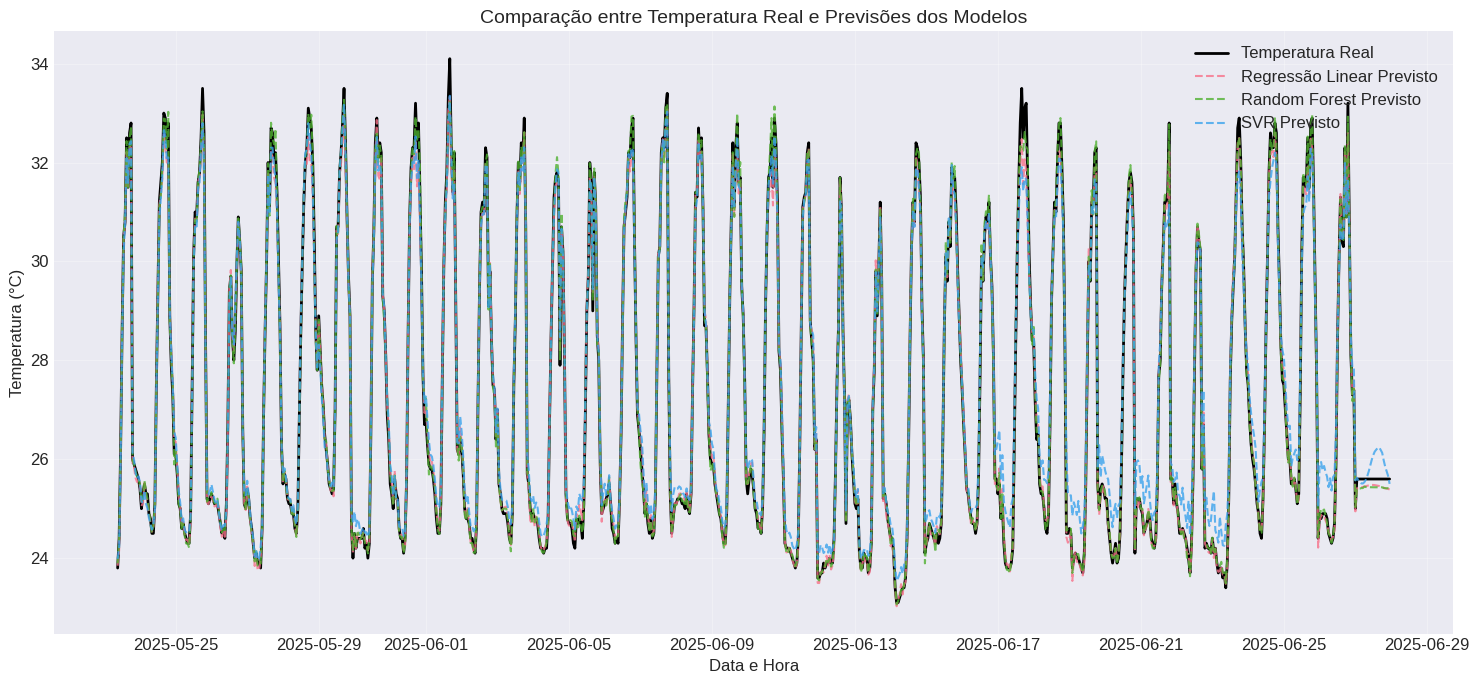

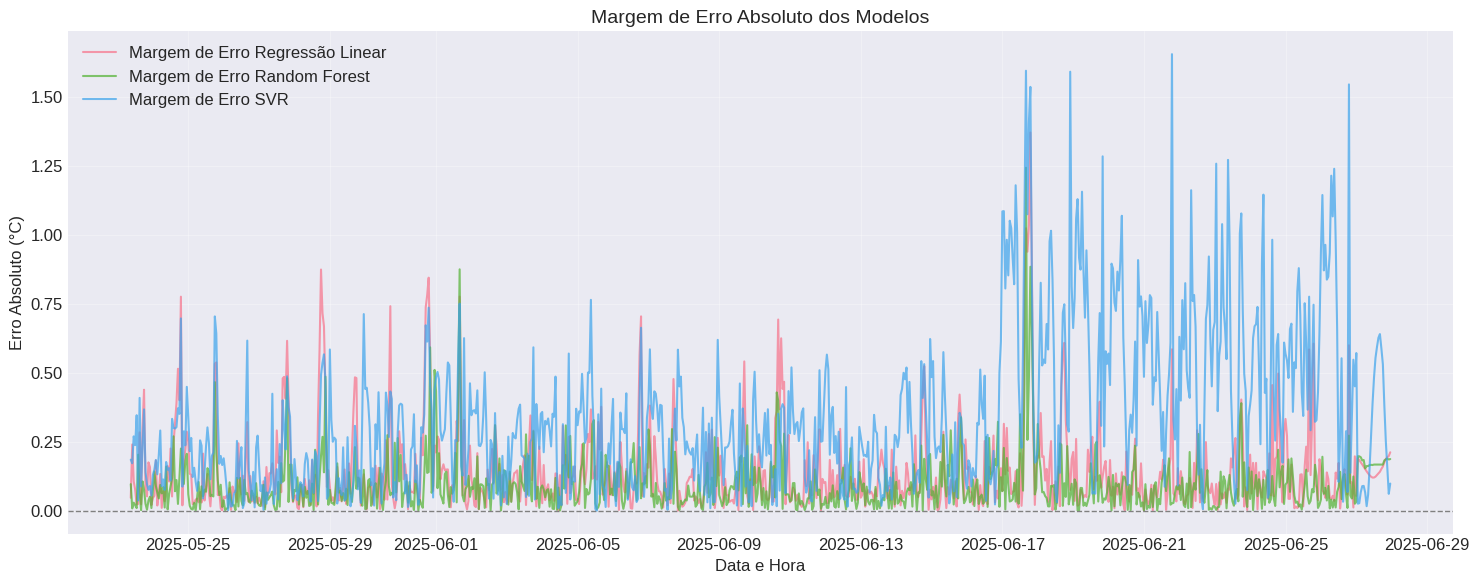

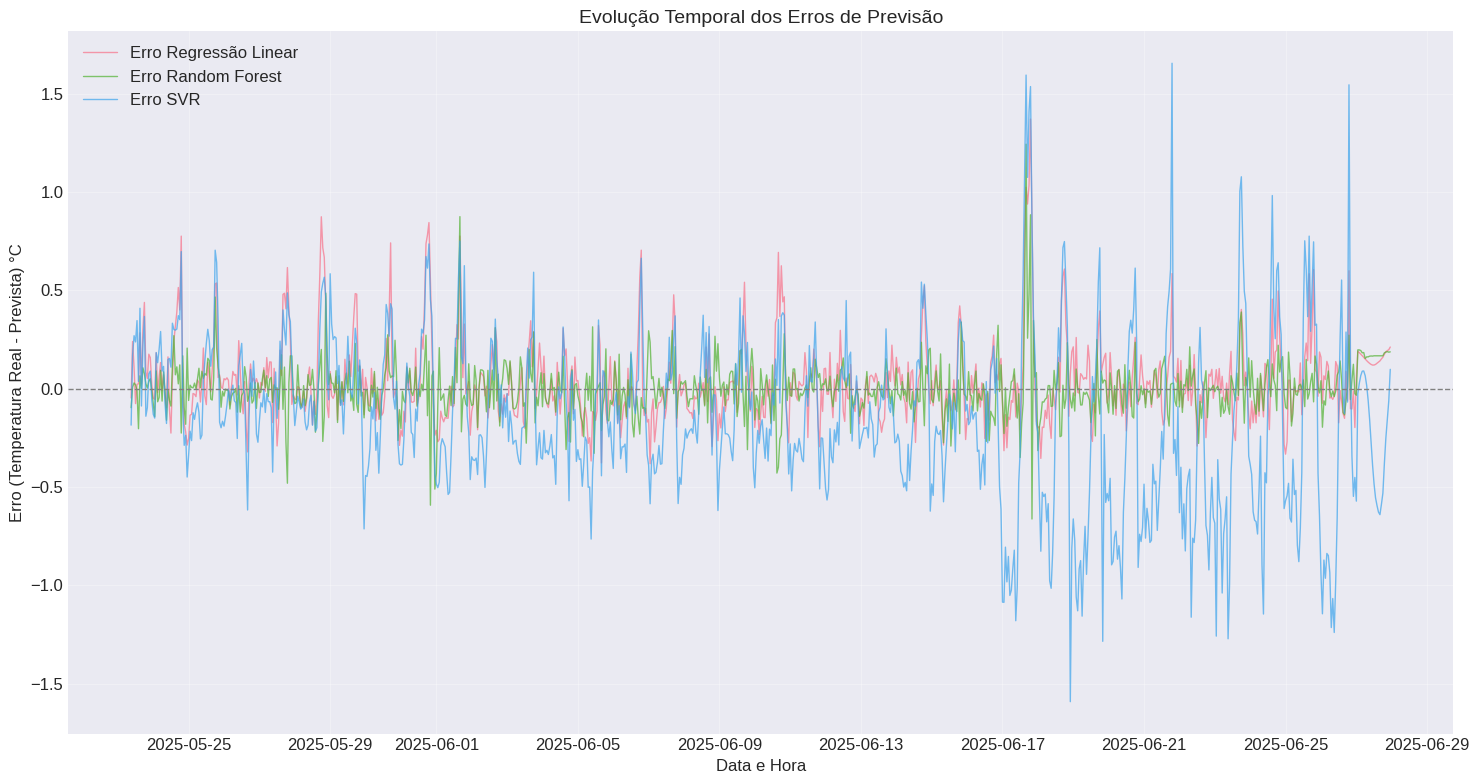

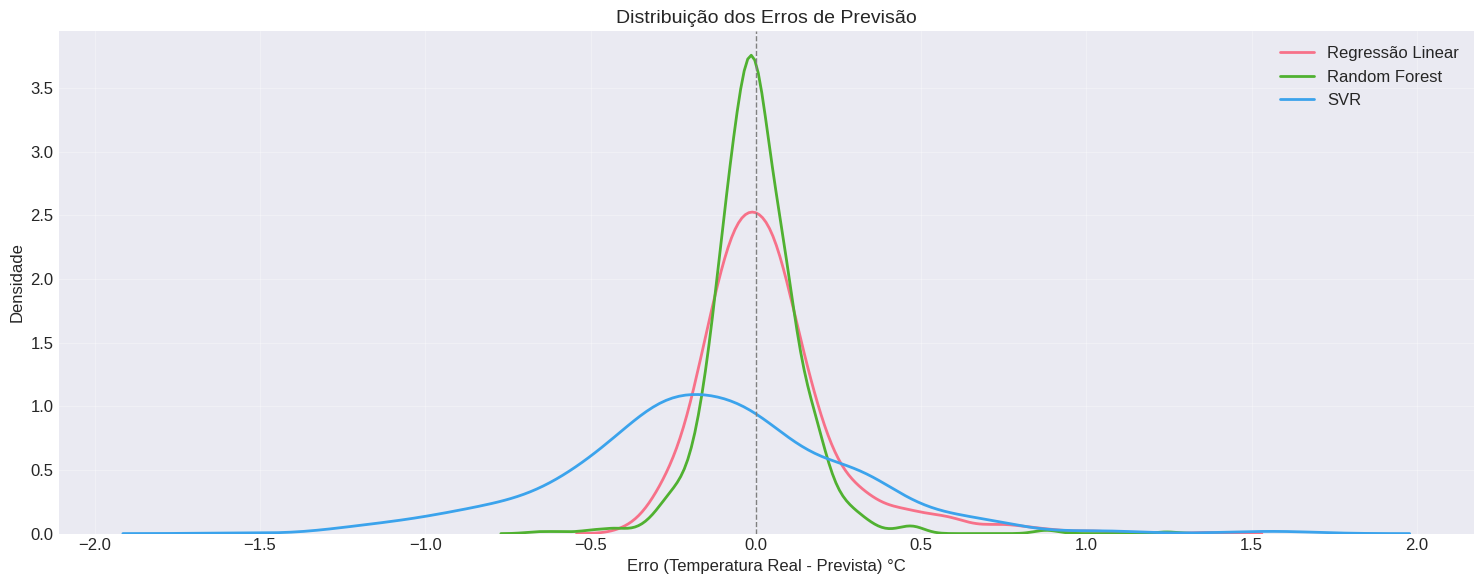

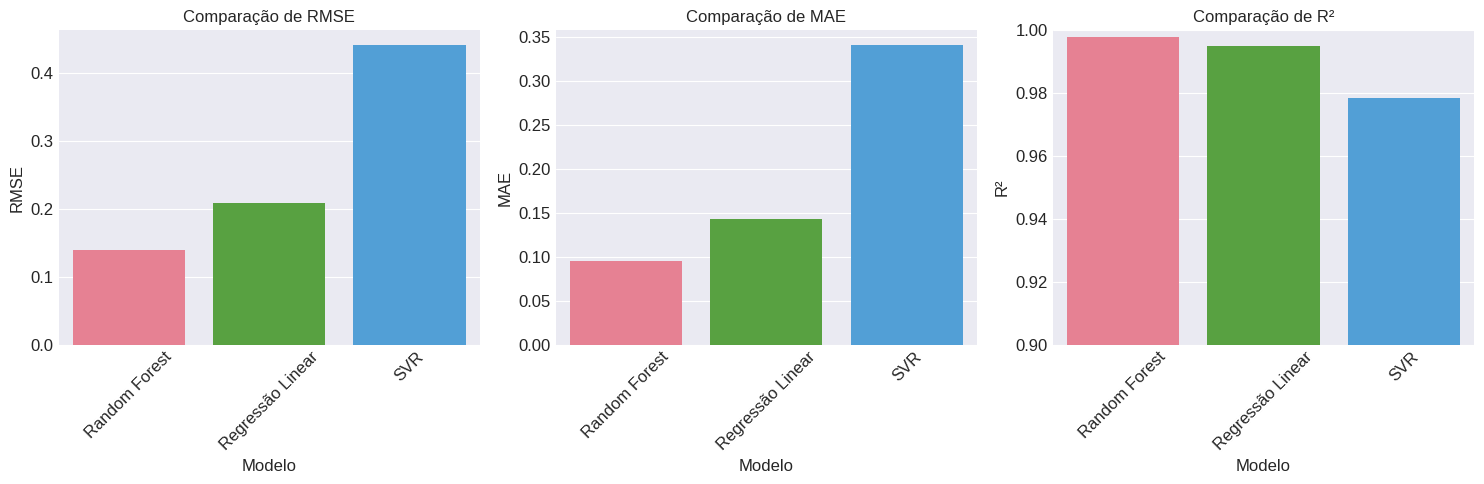

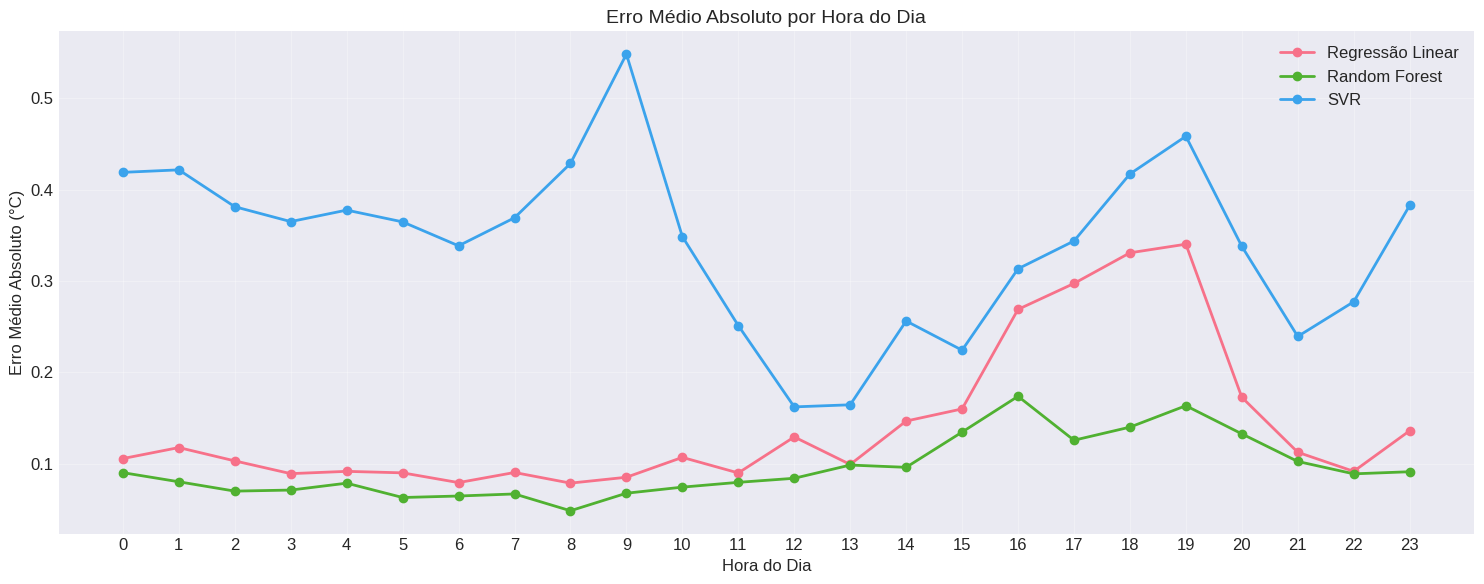


💾 PASSO 8: Salvando resultados...
✅ Resultados salvos em arquivos CSV

🎉 ANÁLISE CONCLUÍDA COM SUCESSO!
🎨 DASHBOARD VISUAL COMPLETO GERADO!


In [93]:
# =============================================================================
# SEÇÃO 8: EXECUÇÃO DO PROGRAMA
# =============================================================================
# Esta seção executa o programa principal

if __name__ == "__main__":
    main()